# 90-Day Repeat-Purchase Propensity Modelling

This notebook develops and evaluates classification models for predicting
whether an existing customer will make another valid merchandise purchase
within the following 90 days.

The modelling dataset was constructed in the previous notebook using a fixed
historical cutoff. All predictor variables therefore represent information
available at prediction time, while the binary target indicates whether a
purchase occurred during the subsequent 90-day observation window.

The modelling workflow will create a stratified training/test split, establish a simple dummy-classifier benchmark, develop an interpretable Logistic Regression baseline, compare it with tree-based classification models, evaluate models using discrimination and positive-class metrics rather than accuracy alone, inspect the most important predictive signals; and translate the final model into a practical customer-targeting interpretation.

Preprocessing and model fitting are performed using the training data only so that the held-out test set remains independent until final evaluation.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests

from pathlib import Path
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import (
    HistGradientBoostingClassifier,
    RandomForestClassifier
)
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    brier_score_loss,
    confusion_matrix,
    f1_score,
    make_scorer,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve
)
from sklearn.model_selection import (
    StratifiedKFold,
    cross_val_predict,
    cross_validate,
    train_test_split
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (
    FunctionTransformer,
    StandardScaler
)


REPO_ROOT = (
    Path.cwd().parent
    if Path.cwd().name == "notebooks"
    else Path.cwd()
)

FIGURES_DIR = REPO_ROOT / "reports" / "figures"
TABLES_DIR = REPO_ROOT / "reports" / "tables"

FIGURES_DIR.mkdir(
    parents=True,
    exist_ok=True
)

TABLES_DIR.mkdir(
    parents=True,
    exist_ok=True
)

In [2]:
LOCAL_DATA_PATH = (
    REPO_ROOT
    / "data"
    / "processed"
    / "propensity_dataset.parquet"
)

DATA_URL = (
    "https://raw.githubusercontent.com/"
    "apostolis-bloutsos-data/"
    "customer-segmentation-purchase-propensity/"
    "main/data/processed/propensity_dataset.parquet"
)

if LOCAL_DATA_PATH.exists():
    df = pd.read_parquet(LOCAL_DATA_PATH)
    print("Loaded local propensity dataset.")

else:
    response = requests.get(DATA_URL, timeout=120)
    response.raise_for_status()

    LOCAL_DATA_PATH.parent.mkdir(
        parents=True,
        exist_ok=True
    )

    LOCAL_DATA_PATH.write_bytes(
        response.content
    )

    df = pd.read_parquet(
        LOCAL_DATA_PATH
    )

    print("Downloaded propensity dataset from GitHub.")

print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")

Loaded local propensity dataset.
Rows: 5,256
Columns: 18


## Train/test split and baseline

The propensity dataset contains one observation per eligible customer, with all
predictors measured at the same historical cutoff and the target measured over
the same subsequent 90-day period.

The dataset is split at customer level into training and held-out test sets.
Because every customer shares the same feature cutoff and prediction window,
a stratified random split is used rather than splitting customers by transaction
date. Stratification preserves the approximately 43.5% / 56.5% target distribution
in both subsets.

The test set is held aside throughout model development. Preprocessing choices,
model fitting and model comparison are performed using the training data only.

A dummy classifier is evaluated first to establish the minimum predictive
benchmark that subsequent models must improve upon.

In [3]:
# Define the predictor columns as determined in the previous notebook

predictor_columns = [
    "recency_days",
    "frequency",
    "monetary_value",
    "total_items",
    "unique_products",
    "average_order_value",
    "tenure_days",
    "purchases_last_90d",
    "monetary_last_90d",
    "items_last_90d",
    "unique_products_last_90d",
    "cancellation_count",
    "cancellation_value",
    "cancellation_value_rate"
]

X = df[predictor_columns].copy()
y = df["repeat_purchase_90d"].copy()

customer_ids = df["customer_id"].copy()

`customer_id` is excluded because it is an identifier rather than a meaningful
behavioural predictor.

`first_purchase_date` and `last_purchase_date` are also excluded from direct
model input because their relevant temporal information is already represented
more appropriately through `tenure_days` and `recency_days`.


In [4]:
# Performs the train/test split

(
    X_train,
    X_test,
    y_train,
    y_test,
    customer_id_train,
    customer_id_test
) = train_test_split(
    X,
    y,
    customer_ids,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [5]:
# Validates the train/test split

print(f"Training customers: {len(X_train):,}")
print(f"Test customers:     {len(X_test):,}")

print()
print("Training target distribution:")
print(y_train.value_counts(normalize=True).mul(100).round(2))

print()
print("Test target distribution:")
print(y_test.value_counts(normalize=True).mul(100).round(2))

Training customers: 4,204
Test customers:     1,052

Training target distribution:
repeat_purchase_90d
0    56.49
1    43.51
Name: proportion, dtype: float64

Test target distribution:
repeat_purchase_90d
0    56.46
1    43.54
Name: proportion, dtype: float64


In [6]:
assert len(X_train) + len(X_test) == len(df)
assert set(X_train.index).isdisjoint(set(X_test.index))
assert X_train.notna().all().all()
assert X_test.notna().all().all()

print("Train/test split validation passed.")

Train/test split validation passed.


In [7]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scoring = {
    "accuracy": "accuracy",
    "precision": make_scorer(
        precision_score,
        zero_division=0
    ),
    "recall": make_scorer(
        recall_score,
        zero_division=0
    ),
    "f1": make_scorer(
        f1_score,
        zero_division=0
    ),
    "roc_auc": "roc_auc",
    "average_precision": "average_precision"
}

In [8]:
# Establish the minimum predictive benchmark using training data only.

dummy_model = DummyClassifier(
    strategy="prior"
)

dummy_cv = cross_validate(
    dummy_model,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring
)

# Produces the metrics of the baseline model

dummy_cv_results = pd.DataFrame({
    metric: [
        dummy_cv[f"test_{metric}"].mean(),
        dummy_cv[f"test_{metric}"].std()
    ]
    for metric in scoring
}, index=["mean", "std"]).T

dummy_cv_results.round(3)

,mean,std
accuracy,0.565,0.0
precision,0.000,0.0
recall,0.000,0.0
f1,0.000,0.0
roc_auc,0.500,0.0
average_precision,0.435,0.0


In [9]:
dummy_oof_pred = cross_val_predict(
    dummy_model,
    X_train,
    y_train,
    cv=cv,
    method="predict"
)

dummy_confusion_matrix = confusion_matrix(
    y_train,
    dummy_oof_pred
)

dummy_confusion_matrix

array([[2375,    0],
       [1829,    0]])

### Baseline model behaviour

The dummy classifier predicts every customer as a non-repeat purchaser because
this is the majority class.

Using the same training-set cross-validation framework applied to subsequent
candidate models, the baseline achieves approximately **56.5% accuracy** but
identifies none of the actual repeat purchasers. Positive-class precision,
recall and F1 are therefore zero, while ROC-AUC is **0.50**, indicating no
ability to discriminate between future repeat purchasers and non-purchasers.

The result demonstrates why accuracy alone is insufficient for this problem.
A useful propensity model must rank and identify customers who are genuinely
more likely to purchase again rather than simply reproduce the majority class.

The held-out test set is not used for baseline construction or candidate-model
comparison and remains reserved for final model evaluation.

## Logistic Regression benchmark

Logistic Regression is used as our first genuine predictive model because
it provides a simple and interpretable benchmark against which more flexible
tree-based models can later be compared.

Most monetary, purchasing-volume and cancellation predictors are strongly
right-skewed. These variables are transformed using `log1p` before
standardization. `log1p` also handles predictors containing legitimate zeros,
such as recent activity and cancellation measures.

Recency and observed tenure exhibit substantially milder skew and are therefore standardized without logarithmic transformation.

Preprocessing and model fitting are combined in a scikit-learn pipeline.
During cross-validation, transformations and scaling are fitted separately
within each training fold, preventing validation-fold information from
influencing model preparation.

Candidate models are developed using the training set only. The held-out test
set is reserved for final model evaluation.

In [10]:
# Defines preprocessing attribute groups

log_columns = [
    "frequency",
    "monetary_value",
    "total_items",
    "unique_products",
    "average_order_value",
    "purchases_last_90d",
    "monetary_last_90d",
    "items_last_90d",
    "unique_products_last_90d",
    "cancellation_count",
    "cancellation_value",
    "cancellation_value_rate"
]

scale_only_columns = [
    "recency_days",
    "tenure_days"
]

In [11]:
# Constructs the preprocessing pipeline

log_pipeline = Pipeline([
    (
        "log1p",
        FunctionTransformer(
            np.log1p,
            feature_names_out="one-to-one"
        )
    ),
    ("scaler", StandardScaler())
])

preprocessor = ColumnTransformer([
    (
        "log_scaled",
        log_pipeline,
        log_columns
    ),
    (
        "scaled",
        StandardScaler(),
        scale_only_columns
    )
])

In [12]:
logistic_model = Pipeline([
    ("preprocessing", preprocessor),
    (
        "model",
        LogisticRegression(
            max_iter=2000,
            random_state=42
        )
    )
])

In [13]:
logistic_cv = cross_validate(
    logistic_model,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring
)

In [14]:
logistic_cv_results = pd.DataFrame({
    metric: [
        logistic_cv[f"test_{metric}"].mean(),
        logistic_cv[f"test_{metric}"].std()
    ]
    for metric in scoring
}, index=["mean", "std"]).T

logistic_cv_results.round(3)

,mean,std
accuracy,0.729,0.011
precision,0.714,0.008
recall,0.629,0.029
f1,0.669,0.020
roc_auc,0.799,0.006
average_precision,0.771,0.005


In [15]:
# Determining customer's probability while that customer was excluded from model fitting

logistic_oof_prob = cross_val_predict(
    logistic_model,
    X_train,
    y_train,
    cv=cv,
    method="predict_proba"
)[:, 1]

logistic_oof_pred = (
    logistic_oof_prob >= 0.5
).astype(int)

confusion_matrix(
    y_train,
    logistic_oof_pred
)

array([[1915,  460],
       [ 678, 1151]])

In [16]:
print(
    "OOF ROC-AUC:",
    round(
        roc_auc_score(
            y_train,
            logistic_oof_prob
        ),
        3
    )
)

print(
    "OOF Average Precision:",
    round(
        average_precision_score(
            y_train,
            logistic_oof_prob
        ),
        3
    )
)

OOF ROC-AUC: 0.798
OOF Average Precision: 0.77


### Logistic Regression cross-validation results

The Logistic Regression benchmark provides a substantial improvement over the
dummy classifier.

Across five stratified cross-validation folds, the model achieved a mean
**ROC-AUC of 0.799** and **Average Precision of 0.771**, indicating useful
ability to rank customers according to their likelihood of purchasing again
within 90 days. Performance was also relatively stable across folds, with
standard deviations of only 0.006 for ROC-AUC and 0.005 for Average Precision.

At the default probability threshold of 0.50, mean cross-validation performance
was:

- Accuracy: **0.729**
- Precision: **0.714**
- Recall: **0.629**
- F1 score: **0.669**

These results are considerably stronger than the dummy benchmark, which
achieved 56.5% accuracy but identified no repeat purchasers.

The model therefore captures meaningful predictive signal from historical
customer behaviour rather than simply reproducing the majority class.

### Out of fold predictions

To inspect classification behaviour without using the held-out test set,
out of fold (OOF) predictions were generated for the training population.

In OOF prediction, the training data are divided into the same cross-validation
folds used for model evaluation. For each fold, the model is fitted using the
other folds and then predicts the customers in the fold that was excluded from
training. Consequently, every customer's OOF probability is produced by a
model that did not train on that customer.

This provides a realistic set of training-stage predictions that can be used
for confusion-matrix analysis, probability inspection and later threshold
selection without evaluating repeatedly on the final test set.

At the default threshold of 0.50, the OOF confusion matrix was:

- True negatives: **1,915**
- False positives: **460**
- False negatives: **678**
- True positives: **1,151**

The model therefore identified approximately **63% of actual future repeat
purchasers**, while approximately **71% of customers predicted to repeat
actually did so**.

OOF ROC-AUC was **0.798** and OOF Average Precision was **0.770**, closely
matching the mean cross-validation results. This consistency indicates that
the reported Logistic Regression performance is not being driven by a single
unusual validation fold.

The 0.50 classification threshold is not assumed to be the final operating
threshold. Depending on the business objective, a lower threshold could capture
more potential repeat purchasers at the cost of additional false positives,
while a higher threshold could produce a smaller but more precisely targeted
customer group. Threshold selection will therefore be considered separately
from model discrimination.

## Tree-based model benchmarks

The Logistic Regression model assumes that predictor effects can be represented
through a relatively simple linear relationship with the log-odds of repeat
purchase.

However customer behaviour may instead contain nonlinear patterns and interactions.
For example, recent activity may have a different effect for historically
high-frequency customers than for customers with only one previous purchase.

Two tree-based classifiers are therefore evaluated:

- **Random Forest**, which combines many decision trees fitted to different
  bootstrap samples and feature subsets and
- **Histogram Gradient Boosting**, which builds trees sequentially to correct
  errors made by earlier trees.

Tree-based models do not require the logarithmic transformations or feature
scaling used by Logistic Regression. They are therefore trained directly on
the original historical predictor values.

The same five-fold stratified cross-validation procedure and evaluation metrics
are used so that model comparisons remain consistent. The held-out test set
continues to remain untouched.

### Random Forest

In [17]:
random_forest_model = RandomForestClassifier(
    n_estimators=400,
    random_state=42,
    n_jobs=-1
)

In [18]:
# Evaluates using 5-fold stratified sampling for accuracy, precision, recall, f1,roc-auc and average precision

random_forest_cv = cross_validate(
    random_forest_model,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring
)

In [19]:
random_forest_cv_results = pd.DataFrame({
    metric: [
        random_forest_cv[f"test_{metric}"].mean(),
        random_forest_cv[f"test_{metric}"].std()
    ]
    for metric in scoring
}, index=["mean", "std"]).T

random_forest_cv_results.round(3)

,mean,std
accuracy,0.718,0.005
precision,0.698,0.015
recall,0.623,0.013
f1,0.658,0.002
roc_auc,0.789,0.007
average_precision,0.761,0.007


### Histogram Gradient Boosting

In [20]:
# Starts with a relatively simple model

hist_gradient_model = HistGradientBoostingClassifier(
    random_state=42
)

In [21]:
hist_gradient_cv = cross_validate(
    hist_gradient_model,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring
)

In [22]:
hist_gradient_cv_results = pd.DataFrame({
    metric: [
        hist_gradient_cv[f"test_{metric}"].mean(),
        hist_gradient_cv[f"test_{metric}"].std()
    ]
    for metric in scoring
}, index=["mean", "std"]).T

hist_gradient_cv_results.round(3)

,mean,std
accuracy,0.721,0.009
precision,0.702,0.021
recall,0.624,0.027
f1,0.660,0.012
roc_auc,0.784,0.006
average_precision,0.755,0.009


In [23]:
# Builds a comparison table of the model benchmarks

model_comparison = pd.DataFrame({
    "Logistic Regression": logistic_cv_results["mean"],
    "Random Forest": random_forest_cv_results["mean"],
    "HistGradientBoosting": hist_gradient_cv_results["mean"]
}).T

model_comparison.to_csv(
    TABLES_DIR / "model_comparison.csv"
)

model_comparison.round(3)

,accuracy,precision,recall,f1,roc_auc,average_precision
Logistic Regression,0.729,0.714,0.629,0.669,0.799,0.771
Random Forest,0.718,0.698,0.623,0.658,0.789,0.761
HistGradientBoosting,0.721,0.702,0.624,0.660,0.784,0.755


In [24]:
# Dispersion metrics for the different models

model_stability = pd.DataFrame({
    "Logistic Regression ROC-AUC std":
        [logistic_cv_results.loc["roc_auc", "std"]],

    "Random Forest ROC-AUC std":
        [random_forest_cv_results.loc["roc_auc", "std"]],

    "HistGradientBoosting ROC-AUC std":
        [hist_gradient_cv_results.loc["roc_auc", "std"]],

    "Logistic Regression AP std":
        [logistic_cv_results.loc["average_precision", "std"]],

    "Random Forest AP std":
        [random_forest_cv_results.loc["average_precision", "std"]],

    "HistGradientBoosting AP std":
        [hist_gradient_cv_results.loc["average_precision", "std"]]
})

model_stability.index = ["std"]

model_stability.round(3)

,Logistic Regression ROC-AUC std,Random Forest ROC-AUC std,HistGradientBoosting ROC-AUC std,Logistic Regression AP std,Random Forest AP std,HistGradientBoosting AP std
std,0.006,0.007,0.006,0.005,0.007,0.009


### Out-of-fold evaluation for the tree models

In [25]:
random_forest_oof_prob = cross_val_predict(
    random_forest_model,
    X_train,
    y_train,
    cv=cv,
    method="predict_proba",
    n_jobs=-1
)[:, 1]

In [26]:
hist_gradient_oof_prob = cross_val_predict(
    hist_gradient_model,
    X_train,
    y_train,
    cv=cv,
    method="predict_proba"
)[:, 1]

In [27]:
print(
    "Random Forest OOF ROC-AUC:",
    round(
        roc_auc_score(
            y_train,
            random_forest_oof_prob
        ),
        3
    )
)

print(
    "Random Forest OOF Average Precision:",
    round(
        average_precision_score(
            y_train,
            random_forest_oof_prob
        ),
        3
    )
)

print()

print(
    "HistGradientBoosting OOF ROC-AUC:",
    round(
        roc_auc_score(
            y_train,
            hist_gradient_oof_prob
        ),
        3
    )
)

print(
    "HistGradientBoosting OOF Average Precision:",
    round(
        average_precision_score(
            y_train,
            hist_gradient_oof_prob
        ),
        3
    )
)

Random Forest OOF ROC-AUC: 0.789
Random Forest OOF Average Precision: 0.76

HistGradientBoosting OOF ROC-AUC: 0.784
HistGradientBoosting OOF Average Precision: 0.754


### Model comparison and selection

The nonlinear tree-based models did not improve predictive performance over
Logistic Regression.

Across five-fold stratified cross-validation, Logistic Regression achieved the
strongest results across all principal evaluation metrics, including ROC-AUC,
Average Precision, F1 score, precision and recall.

Logistic Regression achieved a mean ROC-AUC of **0.799** and Average Precision
of **0.771**, compared with **0.789 / 0.761** for Random Forest and
**0.784 / 0.755** for Histogram Gradient Boosting.

Out-of-fold predictions showed the same ordering, indicating that the result is
not an artefact of averaging across folds. Performance variability was also low
for all three models.

These results suggest that the historical customer features already separate
repeat purchasers reasonably well through relatively simple relationships.
Additional nonlinear model flexibility does not provide a meaningful gain on
this dataset.

Because the more complex models offer no improvement, further tree-model
hyperparameter tuning is not pursued. Logistic Regression is retained as the
final modelling candidate because it combines the strongest cross-validated
performance with substantially greater simplicity and interpretability.

This decision follows model performance rather than an assumption that a more
complex algorithm should necessarily perform better.

In [28]:
# Fits the selected logistic regression model on the complete training set

logistic_model.fit(X_train, y_train)



Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('log_scaled',
                                                  Pipeline(steps=[('log1p',
                                                                   FunctionTransformer(feature_names_out='one-to-one',
                                                                                       func=<ufunc 'log1p'>)),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['frequency',
                                                   'monetary_value',
                                                   'total_items',
                                                   'unique_products',
                                                   'average_order_value',
                                                   'purchases_last_90d',
                                                   'monetary_last_90d',
                                                   'items_last_90d',
                                                   'unique_products_last_90d',
                                                   'cancellation_count',
                                                   'cancellation_value',
                                                   'cancellation_value_rate']),
                                                 ('scaled', StandardScaler(),
                                                  ['recency_days',
                                                   'tenure_days'])])),
                ('model', LogisticRegression(max_iter=2000, random_state=42))])

In [29]:
feature_names = (
    logistic_model
    .named_steps["preprocessing"]
    .get_feature_names_out()
)

feature_names

array(['log_scaled__frequency', 'log_scaled__monetary_value',
       'log_scaled__total_items', 'log_scaled__unique_products',
       'log_scaled__average_order_value',
       'log_scaled__purchases_last_90d', 'log_scaled__monetary_last_90d',
       'log_scaled__items_last_90d',
       'log_scaled__unique_products_last_90d',
       'log_scaled__cancellation_count', 'log_scaled__cancellation_value',
       'log_scaled__cancellation_value_rate', 'scaled__recency_days',
       'scaled__tenure_days'], dtype=object)

In [30]:
# Extract Logistic Regression coefficients.

coefficients = (
    logistic_model
    .named_steps["model"]
    .coef_[0]
)

coefficient_table = pd.DataFrame({
    "feature": feature_names,
    "coefficient": coefficients
})

coefficient_table["abs_coefficient"] = (
    coefficient_table["coefficient"].abs()
)

coefficient_table = coefficient_table.sort_values(
    "abs_coefficient",
    ascending=False
)

coefficient_table

,feature,coefficient,abs_coefficient
0,log_scaled__frequency,0.438030,0.438030
12,scaled__recency_days,-0.420343,0.420343
5,log_scaled__purchases_last_90d,0.369853,0.369853
1,log_scaled__monetary_value,0.323397,0.323397
8,log_scaled__unique_products_last_90d,0.307863,0.307863
13,scaled__tenure_days,-0.271103,0.271103
7,log_scaled__items_last_90d,-0.267829,0.267829
9,log_scaled__cancellation_count,0.221579,0.221579
3,log_scaled__unique_products,0.209406,0.209406
6,log_scaled__monetary_last_90d,-0.157939,0.157939


In [31]:
# Remove preprocessing prefixes for readability.

coefficient_table["feature"] = (
    coefficient_table["feature"]
    .str.replace("log_scaled__", "", regex=False)
    .str.replace("scaled__", "", regex=False)
)

coefficient_table[
    ["feature", "coefficient", "abs_coefficient"]
].round(3).to_csv(
    TABLES_DIR / "logistic_coefficients.csv",
    index=False
)

coefficient_table[
    ["feature", "coefficient"]
].round(3)

,feature,coefficient
0,frequency,0.438
12,recency_days,-0.420
5,purchases_last_90d,0.370
1,monetary_value,0.323
8,unique_products_last_90d,0.308
13,tenure_days,-0.271
7,items_last_90d,-0.268
9,cancellation_count,0.222
3,unique_products,0.209
6,monetary_last_90d,-0.158


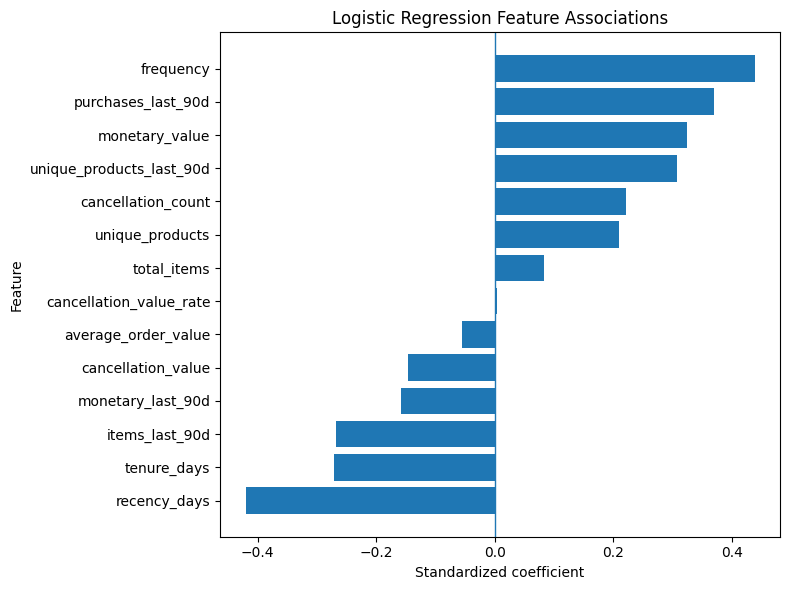

In [32]:
coefficient_plot = (
    coefficient_table[
        ["feature", "coefficient"]
    ]
    .sort_values("coefficient")
)

plt.figure(figsize=(8, 6))

plt.barh(
    coefficient_plot["feature"],
    coefficient_plot["coefficient"]
)

plt.axvline(
    0,
    linewidth=1
)

plt.xlabel("Standardized coefficient")
plt.ylabel("Feature")
plt.title(
    "Logistic Regression Feature Associations"
)

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "logistic_coefficients.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Positive coefficients are associated with a higher predicted probability of
repeat purchase, while negative coefficients are associated with a lower
predicted probability, holding the other predictors constant.

Because the predictors are standardized within the modelling pipeline, the
coefficient magnitudes provide a useful indication of their relative influence
within this Logistic Regression model. However, several predictors are strongly
correlated, so individual coefficients should not be interpreted as isolated
causal effects.

### Logistic Regression coefficient interpretation

The strongest positive coefficients are associated with **historical purchase
frequency**, **purchase activity during the most recent 90 days**, **historical
monetary value**, and **recent product breadth**. These results suggest that
customers who have purchased repeatedly, have remained recently active, have
generated greater historical value, and have recently purchased across a wider
range of products tend to have higher repeat-purchase propensity.

**Recency** has one of the largest coefficients in absolute magnitude and is
negative. This is intuitively consistent with the prediction objective:
customers whose most recent purchase occurred further in the past are less
likely to purchase again during the following 90 days.

Some coefficients require more cautious interpretation. For example,
`items_last_90d` and `monetary_last_90d` have negative coefficients even though
recent purchase count and recent product breadth are positive. Similarly,
historical cancellation count is positive while cancellation value is negative.
These apparently contrasting signs can arise because the predictors contain
overlapping information. Logistic Regression estimates the contribution of
each variable while holding the others constant, so correlated variables can
produce conditional or suppression effects that differ from their simple
univariate relationships.

Observed tenure also has a negative coefficient after controlling for recency,
frequency, value and recent activity. This should therefore not be interpreted
as evidence that long-standing customers are inherently less valuable. Rather,
among customers with otherwise similar recorded behaviour, longer observed
tenure contributes slightly negatively to the model's repeat-purchase estimate.

`cancellation_value_rate` has a coefficient very close to zero, while
`average_order_value` and `total_items` also have comparatively small
coefficients. Once frequency, recency, monetary value and recent behaviour are
included, these variables appear to contribute relatively little additional
linear predictive information.

Overall, the model appears to rely most strongly on a combination of
**purchase frequency, recency, recent activity and historical customer value**.
The coefficients describe predictive associations within the fitted model and
should not be interpreted as causal relationships.

## Out-of-fold threshold selection

The Logistic Regression model produces probabilities rather than
fixed class labels. The conventional classification threshold of 0.50 is
therefore only a default operating rule and does not necessarily provide the
most useful balance between identifying future repeat purchasers and avoiding
false-positive targeting.

Threshold selection is performed using the Logistic Regression out-of-fold
probabilities from the training population. Each of these probabilities was
generated by a model that had not been trained on the corresponding customer,
making them suitable for threshold analysis without consulting the held-out
test set.

Lower thresholds classify more customers as likely repeat purchasers and
typically increase recall at the expense of precision. Higher thresholds create
a smaller, more selective target group, usually increasing precision while
reducing recall.

Because no explicit financial cost has been specified for false positives and
false negatives, several candidate thresholds are compared. F1 score is used
as a useful reference for balancing precision and recall, but the final
operating threshold is interpreted in business terms rather than selected
mechanically.

In [33]:
thresholds = [
    0.20,
    0.30,
    0.40,
    0.50,
    0.60,
    0.70,
    0.80
]

threshold_results = []

for threshold in thresholds:
    pred = (
        logistic_oof_prob >= threshold
    ).astype(int)

    threshold_results.append({
        "threshold": threshold,
        "targeted_customers": pred.sum(),
        "targeted_pct": pred.mean() * 100,
        "accuracy": accuracy_score(
            y_train,
            pred
        ),
        "precision": precision_score(
            y_train,
            pred,
            zero_division=0
        ),
        "recall": recall_score(
            y_train,
            pred,
            zero_division=0
        ),
        "f1": f1_score(
            y_train,
            pred,
            zero_division=0
        )
    })

threshold_table = pd.DataFrame(
    threshold_results
)

threshold_table.round(3).to_csv(
    TABLES_DIR / "threshold_comparison.csv",
    index=False
)

threshold_table.round(3)

,threshold,targeted_customers,targeted_pct,accuracy,precision,recall,f1
0,0.2,3245,77.188,0.601,0.524,0.929,0.670
1,0.3,2596,61.751,0.681,0.594,0.844,0.697
2,0.4,2077,49.405,0.722,0.659,0.748,0.700
3,0.5,1611,38.321,0.729,0.714,0.629,0.669
4,0.6,1225,29.139,0.715,0.757,0.507,0.607
5,0.7,825,19.624,0.699,0.841,0.379,0.523
6,0.8,503,11.965,0.662,0.907,0.249,0.391


In [34]:
# Finds the best threshold in terms of F1 scoring

threshold_grid = np.arange(
    0.05,
    0.951,
    0.01
)

f1_results = []

for threshold in threshold_grid:
    pred = (
        logistic_oof_prob >= threshold
    ).astype(int)

    f1_results.append({
        "threshold": threshold,
        "precision": precision_score(
            y_train,
            pred,
            zero_division=0
        ),
        "recall": recall_score(
            y_train,
            pred,
            zero_division=0
        ),
        "f1": f1_score(
            y_train,
            pred,
            zero_division=0
        ),
        "targeted_pct": pred.mean() * 100
    })

f1_threshold_table = pd.DataFrame(
    f1_results
)

best_f1_row = (
    f1_threshold_table
    .sort_values(
        "f1",
        ascending=False
    )
    .iloc[0]
)

pd.DataFrame({
    "metric": best_f1_row.index,
    "value": best_f1_row.values
}).round(3)

,metric,value
0,threshold,0.390
1,precision,0.653
2,recall,0.759
3,f1,0.702
4,targeted_pct,50.618


In [35]:
# Finds the threshold with the smaller gap between precision and recall

f1_threshold_table[
    "precision_recall_gap"
] = (
    f1_threshold_table["precision"]
    - f1_threshold_table["recall"]
).abs()

balanced_row = (
    f1_threshold_table
    .sort_values(
        "precision_recall_gap"
    )
    .iloc[0]
)

pd.DataFrame({
    "metric": balanced_row.index,
    "value": balanced_row.values
}).round(3)


,metric,value
0,threshold,0.450
1,precision,0.683
2,recall,0.688
3,f1,0.686
4,targeted_pct,43.792
5,precision_recall_gap,0.004


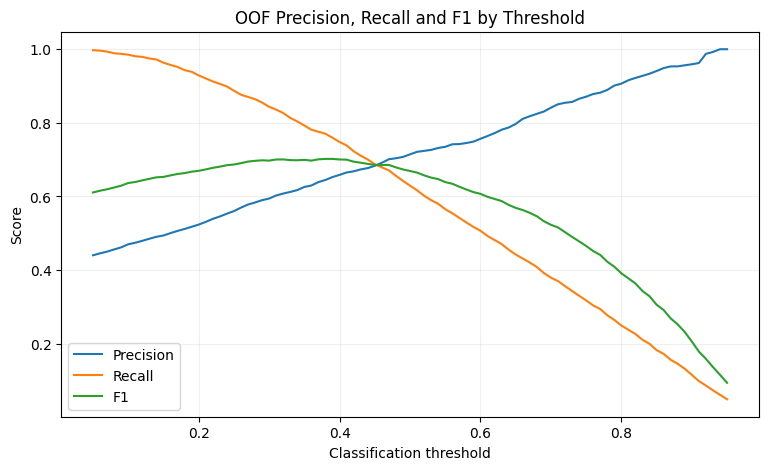

In [36]:
plt.figure(figsize=(9, 5))

plt.plot(
    f1_threshold_table["threshold"],
    f1_threshold_table["precision"],
    label="Precision"
)

plt.plot(
    f1_threshold_table["threshold"],
    f1_threshold_table["recall"],
    label="Recall"
)

plt.plot(
    f1_threshold_table["threshold"],
    f1_threshold_table["f1"],
    label="F1"
)

plt.xlabel("Classification threshold")
plt.ylabel("Score")
plt.title(
    "OOF Precision, Recall and F1 by Threshold"
)
plt.legend()
plt.grid(alpha=0.2)

plt.savefig(
    FIGURES_DIR / "oof_threshold_precision_recall_f1.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [37]:
# Finds the best F1 threshold

best_threshold = float(
    best_f1_row["threshold"]
)

best_oof_pred = (
    logistic_oof_prob >= best_threshold
).astype(int)

best_confusion_matrix = confusion_matrix(
    y_train,
    best_oof_pred
)

best_confusion_matrix

array([[1636,  739],
       [ 440, 1389]])

In [38]:
tn, fp, fn, tp = (
    best_confusion_matrix.ravel()
)

print(
    f"Selected threshold: "
    f"{best_threshold:.2f}"
)

print(
    f"Customers classified as likely repeat purchasers: "
    f"{best_oof_pred.sum():,} "
    f"({best_oof_pred.mean() * 100:.1f}%)"
)

print(
    f"True repeat purchasers captured: "
    f"{tp:,} of {tp + fn:,} "
    f"({tp / (tp + fn) * 100:.1f}%)"
)

print(
    f"Precision among targeted customers: "
    f"{tp / (tp + fp) * 100:.1f}%"
)

Selected threshold: 0.39
Customers classified as likely repeat purchasers: 2,128 (50.6%)
True repeat purchasers captured: 1,389 of 1,829 (75.9%)
Precision among targeted customers: 65.3%


### Threshold analysis and operating threshold selection

The default classification threshold of 0.50 does not provide the best
precision-recall trade-off for this application.

Using out-of-fold predictions from the training population, lowering the
threshold increases the proportion of customers identified as likely repeat
purchasers and substantially improves recall, at the cost of lower precision.

The maximum observed OOF F1 score occurs at a threshold of approximately
**0.39**, where the model targets 50.6% of customers, captures 75.9% of actual
repeat purchasers and achieves 65.3% precision.

However, the nearby threshold of **0.40** produces virtually identical
performance, with an F1 score of **0.700** compared with **0.702** at 0.39.
At 0.40, approximately 49.4% of customers are classified as likely repeat
purchasers, precision is 65.9% and recall is 74.8%.

A threshold of **0.40 is therefore selected as the operating threshold**.
This rounded value provides a simple and interpretable decision rule while
avoiding over-optimizing the threshold to minor variation in the training
sample.

The selected threshold reflects a balanced targeting objective in the absence
of explicit campaign-contact costs or customer-lifetime-value estimates. In a
real deployment, the operating threshold should ultimately be determined using
the economic consequences of false positives and false negatives rather than
classification metrics alone.

In [39]:
SELECTED_THRESHOLD = 0.40

In [40]:
print(f"OOF F1-optimal threshold: {best_threshold:.2f}")
print(f"Selected operating threshold: {SELECTED_THRESHOLD:.2f}")

OOF F1-optimal threshold: 0.39
Selected operating threshold: 0.40


## Final held-out test evaluation

Model selection and operating-threshold selection are now complete using only
the training population.

The selected Logistic Regression pipeline is fitted on the complete training
set and evaluated once on the previously held-out test population using the
pre-selected operating threshold of **0.40**.

In [41]:
logistic_model.fit(
    X_train,
    y_train
)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('log_scaled',
                                                  Pipeline(steps=[('log1p',
                                                                   FunctionTransformer(feature_names_out='one-to-one',
                                                                                       func=<ufunc 'log1p'>)),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['frequency',
                                                   'monetary_value',
                                                   'total_items',
                                                   'unique_products',
                                                   'average_order_value',
                                                   'purchases_last_90d',
                                                   'monetary_last_90d',
                                                   'items_last_90d',
                                                   'unique_products_last_90d',
                                                   'cancellation_count',
                                                   'cancellation_value',
                                                   'cancellation_value_rate']),
                                                 ('scaled', StandardScaler(),
                                                  ['recency_days',
                                                   'tenure_days'])])),
                ('model', LogisticRegression(max_iter=2000, random_state=42))])

In [42]:
test_prob = logistic_model.predict_proba(
    X_test
)[:, 1]

In [43]:
test_pred = (
    test_prob >= SELECTED_THRESHOLD
).astype(int)

In [44]:
final_test_results = {
    "accuracy": accuracy_score(
        y_test,
        test_pred
    ),
    "precision": precision_score(
        y_test,
        test_pred,
        zero_division=0
    ),
    "recall": recall_score(
        y_test,
        test_pred,
        zero_division=0
    ),
    "f1": f1_score(
        y_test,
        test_pred,
        zero_division=0
    ),
    "roc_auc": roc_auc_score(
        y_test,
        test_prob
    ),
    "average_precision": average_precision_score(
        y_test,
        test_prob
    ),
    "brier_score": brier_score_loss(
        y_test,
        test_prob
    )
}


In [45]:
final_test_metrics_table = pd.DataFrame({
    "metric": final_test_results.keys(),
    "value": final_test_results.values()
})

final_test_metrics_table["value"] = (
    final_test_metrics_table["value"]
    .round(3)
)

final_test_metrics_table.to_csv(
    TABLES_DIR / "final_test_metrics.csv",
    index=False
)

final_test_metrics_table

,metric,value
0,accuracy,0.708
1,precision,0.646
2,recall,0.729
3,f1,0.685
4,roc_auc,0.786
5,average_precision,0.759
6,brier_score,0.184


In [46]:
final_confusion_matrix = confusion_matrix(
    y_test,
    test_pred
)

final_confusion_matrix

array([[411, 183],
       [124, 334]])

In [47]:
tn, fp, fn, tp = (
    final_confusion_matrix.ravel()
)

print(
    f"Customers classified as likely repeat purchasers: "
    f"{test_pred.sum():,} of {len(test_pred):,} "
    f"({test_pred.mean() * 100:.1f}%)"
)

print(
    f"Actual repeat purchasers captured: "
    f"{tp:,} of {tp + fn:,} "
    f"({tp / (tp + fn) * 100:.1f}%)"
)

print(
    f"Precision among targeted customers: "
    f"{tp / (tp + fp) * 100:.1f}%"
)

Customers classified as likely repeat purchasers: 517 of 1,052 (49.1%)
Actual repeat purchasers captured: 334 of 458 (72.9%)
Precision among targeted customers: 64.6%


### Held-out performance interpretation

After model selection and operating-threshold selection were completed using
only the training population, the Logistic Regression pipeline was fitted on
the complete training set and evaluated once on the previously untouched
held-out test set.

Using the pre-selected operating threshold of **0.40**, the model achieved:

- **Accuracy:** 0.708
- **Precision:** 0.646
- **Recall:** 0.729
- **F1 score:** 0.685
- **ROC-AUC:** 0.786
- **Average Precision:** 0.759

The held-out test set contained 1,052 customers, including 458 who actually
made another valid purchase during the following 90 days. The model identified
334 of these repeat purchasers, corresponding to **72.9% recall**.

A total of 517 customers, or **49.1% of the held-out population**, were
classified as likely repeat purchasers. Of those targeted customers, **64.6%**
actually purchased again during the 90-day period.

The test confusion matrix contained:

- **411 true negatives**
- **183 false positives**
- **124 false negatives**
- **334 true positives**

Performance on the unseen test population is slightly lower than the
cross-validated training estimates but remains close to them. ROC-AUC declined
from approximately 0.798 out-of-fold to 0.786 on the held-out sample, while
Average Precision declined from approximately 0.770 to 0.759.

This relatively small deterioration suggests that the model generalizes
reasonably well to customers that were not involved in model development.

From a targeting perspective, the selected threshold provides a practical
trade-off: approximately half of customers would be selected while almost
three quarters of the customers who subsequently purchase are captured.

The threshold should not be interpreted as universally optimal. In a real
commercial deployment, campaign costs, expected customer value and the relative
costs of false-positive and false-negative decisions should be incorporated
into threshold selection.

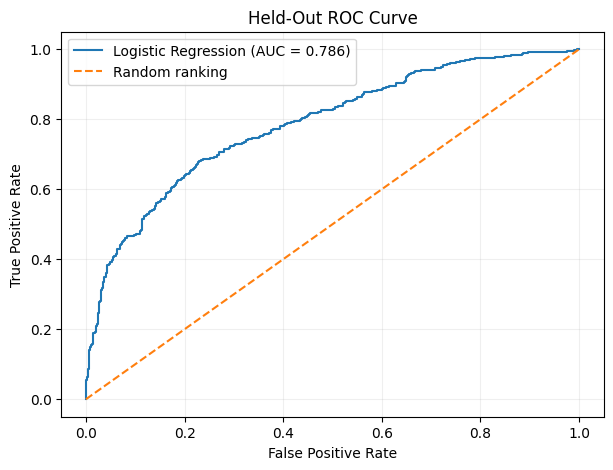

In [48]:
fpr, tpr, _ = roc_curve(
    y_test,
    test_prob
)

plt.figure(figsize=(7, 5))

plt.plot(
    fpr,
    tpr,
    label=f"Logistic Regression (AUC = {final_test_results['roc_auc']:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random ranking"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Held-Out ROC Curve")
plt.legend()
plt.grid(alpha=0.2)

plt.savefig(
    FIGURES_DIR / "heldout_roc_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Held-out ROC curve

The held-out ROC curve remains well above the random-ranking diagonal, with a
ROC-AUC of **0.786**.

This indicates that the Logistic Regression model has useful discriminatory
ability: customers who actually purchase again tend to receive higher predicted
propensities than customers who do not.

The held-out ROC-AUC is only slightly below the out-of-fold value of
approximately 0.798, supporting the conclusion that model performance
generalizes reasonably well to unseen customers.

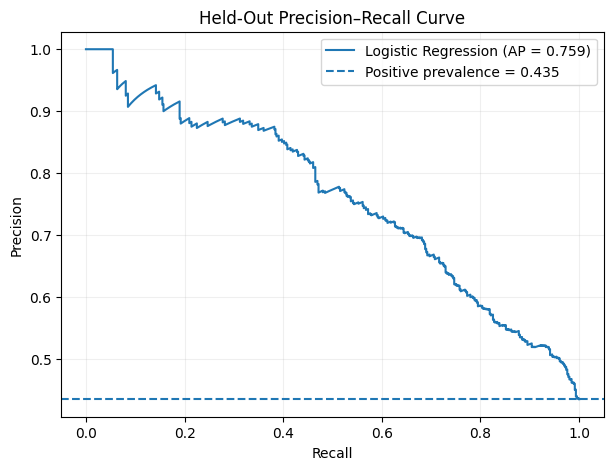

In [49]:
precision_curve, recall_curve, _ = precision_recall_curve(
    y_test,
    test_prob
)

baseline_prevalence = y_test.mean()

plt.figure(figsize=(7, 5))

plt.plot(
    recall_curve,
    precision_curve,
    label=(
        "Logistic Regression "
        f"(AP = {final_test_results['average_precision']:.3f})"
    )
)

plt.axhline(
    baseline_prevalence,
    linestyle="--",
    label=f"Positive prevalence = {baseline_prevalence:.3f}"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Held-Out Precision–Recall Curve")
plt.legend()
plt.grid(alpha=0.2)

plt.savefig(
    FIGURES_DIR / "heldout_precision_recall_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Held-out Precision–Recall curve

The Precision–Recall curve remains substantially above the positive-class
prevalence baseline of approximately **43.5%** across much of the recall range.

The model achieves an Average Precision of **0.759**, showing that customers
with higher predicted propensity are considerably enriched with actual future
repeat purchasers compared with untargeted selection.

As expected, precision declines as recall increases, illustrating the practical
trade-off between targeting a smaller, more concentrated customer group and
capturing a larger share of future purchasers.

In [50]:
test_brier_score = final_test_results[
    "brier_score"
]

print(
    f"Held-out Brier score: "
    f"{test_brier_score:.3f}"
)

Held-out Brier score: 0.184


In [51]:
confusion_matrix_table = pd.DataFrame(
    final_confusion_matrix,
    index=[
        "actual_non_repeat",
        "actual_repeat"
    ],
    columns=[
        "predicted_non_repeat",
        "predicted_repeat"
    ]
)

confusion_matrix_table.to_csv(
    TABLES_DIR / "final_confusion_matrix.csv"
)

confusion_matrix_table

,predicted_non_repeat,predicted_repeat
actual_non_repeat,411,183
actual_repeat,124,334


### Probability quality

The held-out Brier score is **0.184**. The Brier score measures the mean squared
difference between predicted probabilities and actual binary outcomes, with
lower values indicating more accurate probability predictions.

For comparison, predicting the same probability for every customer based only
on the approximately 43.5% repeat-purchase prevalence would produce a Brier
score of roughly **0.246**.

The model therefore provides meaningfully better probability estimates than a
simple prevalence-only benchmark. However, the Brier score alone does not prove
perfect probability calibration, so a dedicated calibration analysis would be
required if highly accurate absolute probabilities were critical to deployment.

In [52]:
# Demonstrates what the model output would actually look like in business use

test_predictions = pd.DataFrame({
    "customer_id": customer_id_test.to_numpy(),
    "actual_repeat_purchase_90d": y_test.to_numpy(),
    "repeat_purchase_probability": test_prob,
    "predicted_repeat_purchase": test_pred
})

test_predictions = (
    test_predictions
    .sort_values(
        "repeat_purchase_probability",
        ascending=False
    )
    .reset_index(drop=True)
)

test_predictions.head(10)

,customer_id,actual_repeat_purchase_90d,repeat_purchase_probability,predicted_repeat_purchase
0,17675,1,0.987013,1
1,17511,1,0.985482,1
2,14298,1,0.985164,1
3,15189,1,0.982166,1
4,12471,1,0.981438,1
5,17243,1,0.978745,1
6,15856,1,0.977153,1
7,14680,1,0.976483,1
8,13078,1,0.975527,1
9,15615,1,0.974654,1


In [53]:
TEST_SCORES_PATH = (
    REPO_ROOT
    / "data"
    / "processed"
    / "test_customer_propensity_scores.parquet"
)

TEST_SCORES_PATH.parent.mkdir(
    parents=True,
    exist_ok=True
)

test_predictions.to_parquet(
    TEST_SCORES_PATH,
    index=False
)

test_scores_check = pd.read_parquet(
    TEST_SCORES_PATH
)

assert len(test_scores_check) == len(X_test)
assert test_scores_check["customer_id"].is_unique

print(
    f"Saved {len(test_scores_check):,} held-out customer scores "
    f"to {TEST_SCORES_PATH}"
)

Saved 1,052 held-out customer scores to /content/data/processed/test_customer_propensity_scores.parquet


## Final modelling conclusions

A leakage-safe classification workflow was developed to predict whether an
existing customer would make another valid merchandise purchase within the
following 90 days.

Three modelling approaches were compared using five-fold stratified
cross-validation on the training population. Logistic Regression outperformed
both Random Forest and Histogram Gradient Boosting across the principal
evaluation metrics, achieving a mean ROC-AUC of **0.799** and Average Precision
of **0.771**.

The absence of improvement from the more flexible tree-based models suggests
that the engineered historical customer features already capture much of the
predictive structure through relatively simple relationships. Logistic
Regression was therefore selected as the final model because it combined the
strongest validation performance with greater simplicity and interpretability.

Model coefficients indicated that repeat-purchase propensity was most strongly
associated with purchase frequency, recency, recent purchase activity,
historical monetary value and recent product breadth. Coefficients were
interpreted as conditional predictive associations rather than causal effects,
particularly because several behavioural variables contain overlapping
information.

The operating classification threshold was selected using training-set
out-of-fold predictions rather than the held-out test set. Although the
maximum F1 score occurred near 0.39, a rounded threshold of **0.40** was chosen
because it produced virtually identical performance while providing a simpler
and more interpretable decision rule.

On the previously untouched held-out sample, the final model achieved a
**ROC-AUC of 0.786**, **Average Precision of 0.759**, **precision of 0.646**,
**recall of 0.729** and **F1 score of 0.685**.

At the selected threshold, the model classified approximately **49% of
customers** as likely repeat purchasers while capturing approximately **73% of
the customers who actually purchased again** during the following 90 days.

Overall, the model provides a practical mechanism for ranking and prioritizing
existing customers according to near-term repeat-purchase propensity. In a
real commercial setting, the final targeting threshold should be refined using
campaign costs, expected customer value and the relative economic consequences
of false-positive and false-negative decisions.

The present evaluation is based on a single historical cutoff and 90-day
prediction window. A stronger production validation would repeat the modelling
process across multiple historical cutoffs to assess temporal stability before
deployment.

## Business integration with customer segmentation

The propensity model provides a tactical prioritization layer that complements
the strategic customer segmentation developed earlier in the project.

In an operational system, both analyses could be recalculated at the same
scoring date. The customer segment would help determine the type of engagement,
while the repeat-purchase propensity score would help determine the priority
or intensity of that engagement.

| Customer segment | Higher repeat-purchase propensity | Lower repeat-purchase propensity |
|---|---|---|
| **High-Value Loyal** | Protect and personalize; prioritize retention and relevant offers | Proactive retention attention because a valuable customer may be cooling |
| **Established At-Risk** | Timely reactivation; the customer still appears receptive | Selective stronger win-back effort based on historical value |
| **Recent Developing** | Nurture, cross-sell and encourage the next purchase | Light engagement and onboarding rather than expensive incentives |
| **Dormant Low-Value** | Low-cost reactivation may still be worthwhile | Lowest priority; avoid costly intervention |

This table represents a proposed decision framework rather than measured
segment-level propensity results. The existing segmentation and propensity
outputs are not directly merged because they were produced using different
historical reference dates.